In [1]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [5]:
#work dir
setwd("/home/mjehangir/telomere-sv-analysis/data/aysa_SVs/")

In [6]:
############################################################
# Somatic SV plotting script
# Input: somatic_svs.csv
############################################################

library(tidyverse)

In [19]:
# -------------------------
# Load data
# -------------------------
sv <- read.csv("somatic_svs_jan19.csv")
head(sv)

,svid,chr1,pos1,chr2,pos2,hvaf,vaf,dv,dr,svtype,genotype,cellline,TCN1,TCN2,region1,region2,region
,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,severus_INS8041,chr1,3010201,chr1,3010201,0.42,0.08,17,185,INS,somatic,2436A,2,2,other,other,other
2,severus_INS8069,chr1,8976617,chr1,8976617,0.00,0.05,3,54,INS,somatic,2436A,2,2,other,other,other
3,severus_INS8086,chr1,15789450,chr1,15789450,0.14,0.06,3,45,INS,somatic,2436A,2,2,other,other,other
4,severus_DUP160,chr1,39784669,chr1,39800629,0.00,0.07,6,80,DUP,somatic,2436A,2,2,other,other,other
5,severus_BND15530,chr1,39784669,chr1,39784669,0.00,0.11,10,82,sBND,somatic,2436A,2,2,other,other,other
6,severus_DUP161,chr1,39784746,chr1,39800822,0.00,0.06,6,87,DUP,somatic,2436A,2,2,other,other,other


In [8]:
# Assuming your data is in a dataframe called df
total_unique_samples <- length(unique(sv$cellline))
total_unique_samples


[1] 20

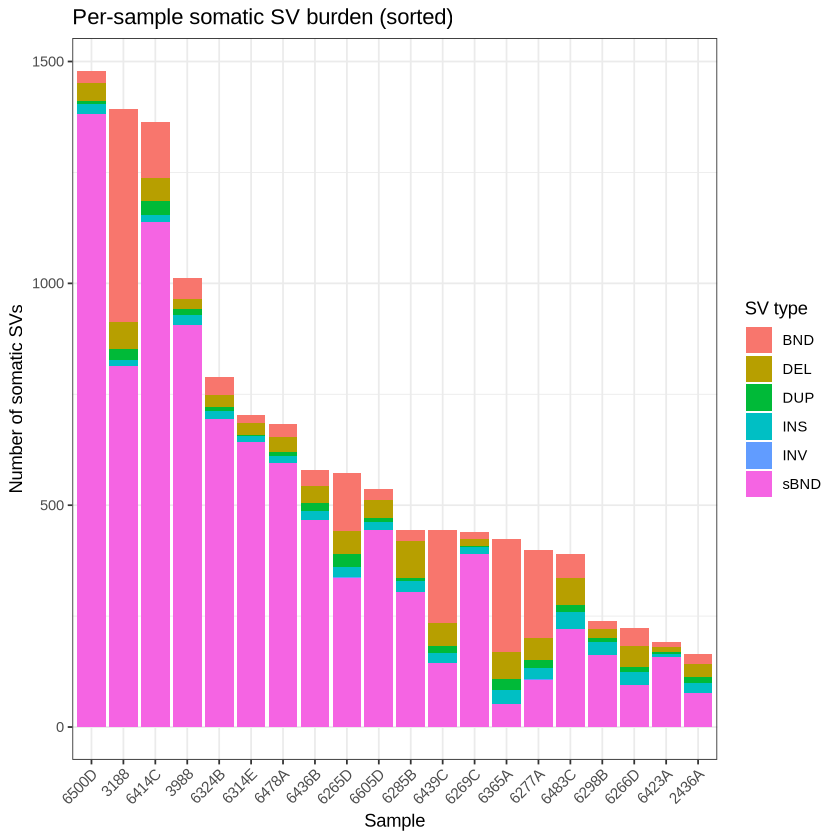

In [9]:
# -------------------------
# Count SVs per sample and type
# -------------------------
sv_counts <- sv %>%
  count(cellline, svtype, name = "n")

#Order samples by total SV count
# -------------------------
sample_order <- sv_counts %>%
  group_by(cellline) %>%
  summarise(total_sv = sum(n)) %>%
  arrange(desc(total_sv)) %>%
  pull(cellline)

sv_counts$cellline <- factor(
  sv_counts$cellline,
  levels = sample_order
)

# -------------------------
# Stacked bar plot
# -------------------------
p <- ggplot(sv_counts, aes(x = cellline, y = n, fill = svtype)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  labs(
    x = "Sample",
    y = "Number of somatic SVs",
    fill = "SV type",
    title = "Per-sample somatic SV burden (sorted)"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

print(p)

In [15]:
library(dplyr)
library(ggplot2)
library(ggpubr)

# 1. Categorize regions and count SVs per sample
# We assume 'region1' or 'region' contains strings like "telomere" or "centromere"
sample_stats <- sv %>%
  group_by(cellline) %>%
  summarise(
    total_sv = n(),
    telomeric_sv = sum(grepl("telomere", region, ignore.case = TRUE)),
    centromeric_sv = sum(grepl("centromere", region, ignore.case = TRUE)),
    regional_total = telomeric_sv + centromeric_sv
  )

library(ggplot2)
library(ggpubr)

# Simple, high-contrast plot for chromosomal or sample burden
p <- ggplot(sample_stats, aes(x = total_sv, y = regional_total)) +
  # Use a single, professional color (e.g., Midnight Blue or Slate)
  geom_point(alpha = 0.5, size = 3, color = "#2c3e50") +
  # Add the regression line and confidence interval
  geom_smooth(method = "lm", color = "black", fill = "grey80", linewidth = 0.8) +
  # Standard Pearson correlation display
  stat_cor(
    aes(label = paste(after_stat(rr.label), after_stat(p.label), sep = "~`,`~")),
    method = "pearson", 
    label.x.npc = "left"
  ) +
  labs(
    x = "Total structural variants",
    y = "Regional (telomeric and centromeric) variants",
    title = "Correlation of chromosomal and regional instability"
  ) +
  # Clean white background with classic axes
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "plain"),
    axis.line = element_line(color = "black")
  )

In [16]:
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/telcent_per-sample.pdf",
  plot = p,
  width = 4,   # inches
  height = 4,  # inches
  units = "in",
  device = "pdf"
)

`geom_smooth()` using formula = 'y ~ x'


In [17]:
library(dplyr)

df2_reshaped <- sv %>%
  # Rename / recode columns to match df1
  mutate(
    chr    = chr1,
    start  = as.integer(pos1),
    end    = as.integer(pos2),
    size   = abs(end - start),
    type   = case_when(
      svtype %in% c("sBND", "BND") ~ "BND",  # merge sBND and BND
      TRUE ~ svtype                          # keep other types as-is
    ),
    sample = cellline
  ) %>%
  # Reorder and keep only the columns of df1
  select(chr, start, end, size, type, sample)

# Preview
head(df2_reshaped)


,chr,start,end,size,type,sample
,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,chr1,3010201,3010201,0,INS,2436A
2,chr1,8976617,8976617,0,INS,2436A
3,chr1,15789450,15789450,0,INS,2436A
4,chr1,39784669,39800629,15960,DUP,2436A
5,chr1,39784669,39784669,0,BND,2436A
6,chr1,39784746,39800822,16076,DUP,2436A


In [85]:
nrow(df2_reshaped)

[1] 12469

In [86]:
write.table(df2_reshaped,
            file = "/scratch/mjehangir/aysa_severus_results/severus_reshaped.tsv",
            sep = "\t",
            quote = FALSE,
            row.names = FALSE)

In [15]:
library(dplyr)
library(readr)

# 1️⃣ Read CNV+TL file (SV columns already removed)
cnv_tl <- read_tsv("aysa_CNV_TL_combined_for_mixed_model.tsv")

# 2️⃣ Read new SV file
sv <- read_tsv("aysa_severus_somatic_sv_summary_rate_prop_pq.tsv")

# 3️⃣ Rename columns in SV to match CNV+TL keys
sv <- sv %>%
  rename(
    Sample_ID = filename,
    chr_arm = region
  )

head(sv)

Rows: 831 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Sample_ID, chr_arm
dbl (6): final_average_TL_p75_kb, norm_TL, cnv_rate_per_mb_Gain, cnv_rate_pe...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1618 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): filename, chr, Arm, type, region
dbl (6): arm_size.y, sv_count, sv_size_sum, chr_arm_length_mb, sv_rate, sv_p...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Sample_ID,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,chr_arm
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2436A,chr1,p,124048267,BND,1,0.000000,124.04827,0.008061378,0.000000e+00,chr1p
2436A,chr1,p,124048267,DUP,2,0.032036,124.04827,0.016122756,2.582543e-04,chr1p
2436A,chr1,p,124048267,INS,4,0.000000,124.04827,0.032245513,0.000000e+00,chr1p
2436A,chr1,q,124339061,BND,2,0.000000,124.33906,0.016085050,0.000000e+00,chr1q
2436A,chr1,q,124339061,DEL,1,0.026438,124.33906,0.008042525,2.126283e-04,chr1q
2436A,chr10,p,40649191,DEL,1,0.003151,40.64919,0.024600736,7.751692e-05,chr10p


In [16]:
head(cnv_tl)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr1p,5.221000,-0.06948662,NA,NA,NA,NA
2436A,chr1q,5.051167,-0.21340301,0.008042525,0.00000000,0.001609727,0.0000000
3188,chr1p,1.642500,-2.95775970,0.000000000,0.01612276,0.000000000,0.3678764
3188,chr1q,3.086500,0.65675845,0.008042525,0.00000000,0.008048565,0.0000000
3988,chr1p,2.347500,-2.53325753,NA,NA,NA,NA
3988,chr1q,5.083000,-0.45973091,NA,NA,NA,NA


In [17]:
# 3️⃣ Aggregate SVs per Sample_ID x chr_arm x type
sv_agg <- sv %>%
  group_by(Sample_ID, chr_arm, type) %>%
  summarise(
    sv_rate = sum(sv_rate),
    sv_proportion = sum(sv_proportion),
    .groups = "drop"
  )

# 4️⃣ Pivot SVs to wide format
sv_wide <- sv_agg %>%
  pivot_wider(
    names_from = type,
    values_from = c(sv_rate, sv_proportion),
    values_fill = 0
  )

# 5️⃣ Rename columns to clean names
names(sv_wide) <- gsub("sv_rate_", "sv_rate_", names(sv_wide))        # keep sv_rate_DEL etc
names(sv_wide) <- gsub("sv_proportion_", "sv_proportion_", names(sv_wide)) # sv_proportion_DEL etc

# 6️⃣ Merge with CNV+TL table
merged_final <- cnv_tl %>%
  select(-starts_with("sv_rate_"), -starts_with("sv_proportion_")) %>% # remove old SV columns if present
  left_join(sv_wide, by = c("Sample_ID", "chr_arm"))

# 7️⃣ Replace any NA with 0 for SV columns
sv_cols <- grep("sv_rate_|sv_proportion_", names(merged_final), value = TRUE)
merged_final[sv_cols] <- lapply(merged_final[sv_cols], function(x) ifelse(is.na(x), 0, x))

In [18]:
head(merged_final)

Sample_ID,chr_arm,final_average_TL_p75_kb,norm_TL,cnv_rate_per_mb_Gain,cnv_rate_per_mb_Loss,cnv_proportion_per_mb_Gain,cnv_proportion_per_mb_Loss,sv_rate_DEL,sv_rate_DUP,sv_rate_BND,sv_rate_INS,sv_rate_INV,sv_proportion_DEL,sv_proportion_DUP,sv_proportion_BND,sv_proportion_INS,sv_proportion_INV
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2436A,chr1p,5.221000,-0.06948662,NA,NA,NA,NA,0.000000000,0.01612276,0.008061378,0.032245513,0,0.000000e+00,0.0002582543,0.0000000,0,0
2436A,chr1q,5.051167,-0.21340301,0.008042525,0.00000000,0.001609727,0.0000000,0.008042525,0.00000000,0.016085050,0.000000000,0,2.126283e-04,0.0000000000,0.0000000,0,0
3188,chr1p,1.642500,-2.95775970,0.000000000,0.01612276,0.000000000,0.3678764,0.032245513,0.00000000,0.386946155,0.008061378,0,8.025102e-05,0.0000000000,0.0000000,0,0
3188,chr1q,3.086500,0.65675845,0.008042525,0.00000000,0.008048565,0.0000000,0.008042525,0.00000000,0.313658473,0.000000000,0,4.447516e-06,0.0000000000,0.0000000,0,0
3988,chr1p,2.347500,-2.53325753,NA,NA,NA,NA,0.000000000,0.00000000,0.330516508,0.016122756,0,0.000000e+00,0.0000000000,0.0000000,0,0
3988,chr1q,5.083000,-0.45973091,NA,NA,NA,NA,0.000000000,0.00000000,0.490594022,0.000000000,0,0.000000e+00,0.0000000000,0.5437668,0,0


In [97]:
write_tsv(merged_final, "mixed_model_SVs_CNV_TL_with_SV_final.tsv")
